In [19]:
import gc
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from contextlib import suppress
from types import SimpleNamespace

from utils import io_utils, ml_utils

In [21]:
cp = SimpleNamespace()
# cp.EXAMPLE_MNAV_SESSION = "/media/naeem_md93/DRIVE/MNAV/Fig1/amadeus08272019_a.mat"
# cp.EXAMPLE_NTS_SESSION = "/media/naeem_md93/DRIVE/MNAV/Fig1/amadeus08292019_a.mat"

cp.EXAMPLE_MNAV_SESSION = "/media/naeem_md93/DRIVE/MNAV/Fig1/mahler03262021_a.mat"
cp.EXAMPLE_NTS_SESSION = "/media/naeem_md93/DRIVE/MNAV/Fig1/mahler03282021_a.mat"

# cp.EXAMPLE_MNAV_SESSION = "/media/naeem_md93/DRIVE/MNAV/EC/mahler04212021_a.mwk/mahler04212021_a.mat"
# cp.EXAMPLE_NTS_SESSION = "/media/naeem_md93/DRIVE/MNAV/EC/mahler04212021_a.mwk/mahler04212021_a.mat"

cp.EXAMPLE_SEQ = 1

# MNAV

In [22]:
with suppress(NameError):
    del nts_data
    del nts_df
    del g_mask
    del gg_mask
    del ggg_mask
    del randtick
    del taa
    del jitter
    del tatplm
    del tatplmall
    del xx

gc.collect()

3602

In [23]:
mnav_data = io_utils.load_mat_file(cp.EXAMPLE_MNAV_SESSION)
print(mnav_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'tr_time', 'tr', 'expfile', 'startid', 'endid', 'start_expt_time', 'start_expt', 'attempt', 'repeatdata', 'maskdecay', 'set', 'seqq', 'showcentre', 'feedbackdelay', 'joy_time', 'joy', 'eyex_time', 'eyex', 'eyey_time', 'eyey', 'delay', 'press', 'ta', 'tp', 'rt', 'succ', 'mask', 'goCue_on_time', 'stim2_on_time', 'trial_start_time', 'repeat_trial_start_time', 'juice_on_time', 'failed_tr', 'joy1_time', 'joy1', 'joy2_time', 'joy2', 'ta2', 'tp2', 'rt2', 'curr', 'target', 'currimg_orig', 'targimg_orig', 'trial_type', 'trial_type_seq', 'trial_transitions', 'trial_transitions_type', 'trial_type_seq_code', 'trial_type_code', 'repeated_trials', 'numrepeat', 'clust', 'clustsize', 'neuron_label', 'spk', 'stable_neuron', 'gocuettl', 'joy1offttl', 'joy1onttl', 'mworks_lead', 'stim1onttl', 'stim2onttl', 't0_mworks', 't0_oe', 'newtpsubsamp', 'newtssubsamp', 'outlier_removal', 'mdlbiasvar', 'mdlcomp', 'newtpsubsamp2', 'newtssubsamp2', 'mdl', 'validt

In [24]:
mnav_df = pd.DataFrame({
    "mask": mnav_data["mask"],
    "seqq": mnav_data["seqq"],
    "tp": mnav_data["tp"],
    "ta": mnav_data["ta"],
    "trial_type": mnav_data["trial_type"],
    "validtrials_mm": mnav_data["validtrials_mm"],
})

mnav_df

,mask,seqq,tp,ta,trial_type,validtrials_mm
0,1.00,2,1.116666,-2.600,2,0
1,1.00,2,2.683319,2.600,2,0
2,1.00,3,1.133334,1.950,2,0
3,1.00,3,1.100000,0.975,2,0
4,1.00,3,2.883333,2.925,2,0
...,...,...,...,...,...,...
3189,0.99,3,1.600000,1.950,1,0
3190,0.99,3,0.416667,-2.925,1,0
3191,0.99,3,999.000000,-2.925,1,0
3192,0.99,3,1.133333,2.925,1,0


In [25]:
g_mask = (
    (mnav_df["mask"] == 1)
    & (mnav_df["seqq"] == cp.EXAMPLE_SEQ)
    & (mnav_df["tp"] < 99)
    & (mnav_df["tp"].abs() > 0.01)
    & (mnav_df["trial_type"] == 3)
    & (mnav_df["validtrials_mm"] == 1)
)

gg_mask = (
    (mnav_df["mask"] == 1)
    & (mnav_df["seqq"] == cp.EXAMPLE_SEQ)
    & (mnav_df["tp"] < 99)
    & (mnav_df["tp"].abs() > 0.01)
    & (mnav_df["trial_type"] == 3)
    & (mnav_df["validtrials_mm"] == 0)
)

randtick = 0.25
ggg_mask = g_mask | gg_mask
taa = np.unique(mnav_df.loc[g_mask, "ta"])
jitter = np.random.random(mnav_df["ta"].shape) * randtick

In [26]:
tatplm = ml_utils.fitlm(
    mnav_df.loc[g_mask, "ta"],
    mnav_df.loc[g_mask, "tp"]
)

tatplmall = ml_utils.fitlm(
    mnav_df.loc[ggg_mask, "ta"],
    mnav_df.loc[ggg_mask, "tp"]
)

xx = np.array([-5, 5])

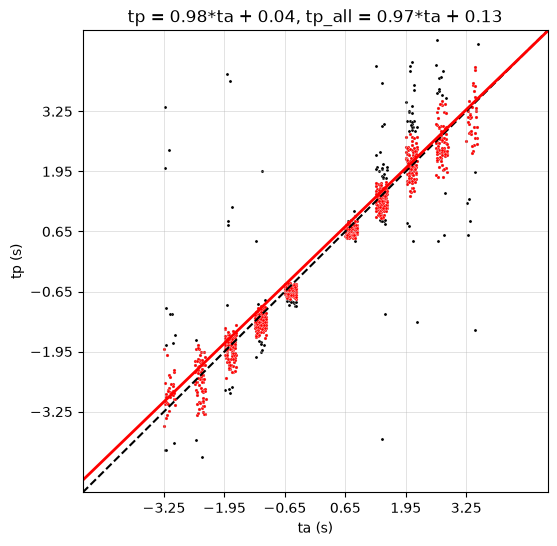

In [27]:
plt.figure(figsize=(6, 6))
sns.scatterplot(
    x=mnav_df.loc[ggg_mask, "ta"] + jitter[ggg_mask],
    y=mnav_df.loc[ggg_mask, "tp"],
    s=5,
    markers="o",
    color="k",
)
sns.scatterplot(
    x=mnav_df.loc[g_mask, "ta"] + jitter[g_mask],
    y=mnav_df.loc[g_mask, "tp"],
    s=5,
    markers="o",
    color="r"
)

sns.lineplot(x=(-5, 5), y=(-5, 5), linestyle="--", color="k")

# sns.lineplot(
#     x=xx,
#     y=tatplm.Coefficients.Estimate[1] * xx + tatplm.Coefficients.Estimate[0],
#     linestyle="--",
#     color="k",
#     linewidth=2
# )

sns.lineplot(
    x=xx,
    y=tatplmall.Coefficients.Estimate[1] * xx + tatplmall.Coefficients.Estimate[0],
    # linestyle="--",
    color="r",
    linewidth=2
)

plt.xlabel("ta (s)")
plt.xticks(np.arange(-3.25, 3.26, 1.3))

plt.ylabel("tp (s)")
plt.yticks(np.arange(-3.25, 3.26, 1.3))

plt.axis((-5, 5, -5, 5))
plt.grid(visible=True)
plt.title(
    f"tp = {round(tatplm.Coefficients.Estimate[1], 2)}*ta + {round(tatplm.Coefficients.Estimate[0], 2)}, "
    f"tp_all = {round(tatplmall.Coefficients.Estimate[1], 2)}*ta + {round(tatplmall.Coefficients.Estimate[0], 2)}"
)

plt.show()

# NTS

In [28]:
with suppress(NameError):
    del mnav_data
    del mnav_df
    del g_mask
    del gg_mask
    del ggg_mask
    del randtick
    del taa
    del jitter
    del tatplm
    del tatplmall
    del xx

gc.collect()

246

In [29]:
nts_data = io_utils.load_mat_file(cp.EXAMPLE_NTS_SESSION)
print(nts_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'tr_time', 'tr', 'expfile', 'startid', 'endid', 'start_expt_time', 'start_expt', 'attempt', 'repeatdata', 'maskdecay', 'set', 'seqq', 'showcentre', 'feedbackdelay', 'joy_time', 'joy', 'eyex_time', 'eyex', 'eyey_time', 'eyey', 'delay', 'press', 'ta', 'tp', 'rt', 'succ', 'mask', 'goCue_on_time', 'stim2_on_time', 'trial_start_time', 'repeat_trial_start_time', 'juice_on_time', 'failed_tr', 'joy1_time', 'joy1', 'joy2_time', 'joy2', 'ta2', 'tp2', 'rt2', 'curr', 'target', 'currimg_orig', 'targimg_orig', 'trial_type', 'trial_type_seq', 'trial_transitions', 'trial_transitions_type', 'trial_type_seq_code', 'trial_type_code', 'repeated_trials', 'numrepeat', 'gocuettl', 'joy1offttl', 'joy1onttl', 'mworks_lead', 'stim1onttl', 'stim2onttl', 't0_mworks', 't0_oe', 'clust', 'clustsize', 'neuron_label', 'spk', 'stable_neuron', 'mdlbiasvar', 'mdlcomp', 'newtpsubsamp2', 'newtssubsamp2', 'mdl', 'validtrials_mm'])


In [30]:
nts_df = pd.DataFrame({
    "seqq": nts_data["seqq"],
    "tp": nts_data["tp"],
    "ta": nts_data["ta"],
    "trial_type": nts_data["trial_type"],
    "validtrials_mm": nts_data["validtrials_mm"],
})

nts_df

,seqq,tp,ta,trial_type,validtrials_mm
0,2,1.400000,-0.65,2,0
1,2,3.599983,-0.65,2,0
2,2,2.633334,2.60,2,0
3,1,1.400000,1.30,2,0
4,1,-3.333333,-3.25,2,0
...,...,...,...,...,...
2601,1,-0.616666,-0.65,1,0
2602,1,0.699977,0.65,1,0
2603,1,3.216643,3.25,1,0
2604,1,-3.049984,-3.25,1,0


In [31]:
g_mask = (
    (nts_df["seqq"] < 3)
    & (nts_df["trial_type"] < 3)
    & (nts_df["tp"] < 4)
    & (nts_df["tp"].abs() > 0.01)
)

randtick = 0.25
taa = np.unique(nts_df.loc[g_mask, "ta"])
jitter = np.random.random(nts_df["ta"].shape) * randtick

In [32]:
tatplm = ml_utils.fitlm(
    nts_df.loc[g_mask, "ta"],
    nts_df.loc[g_mask, "tp"]
)

xx = np.array([-5, 5])

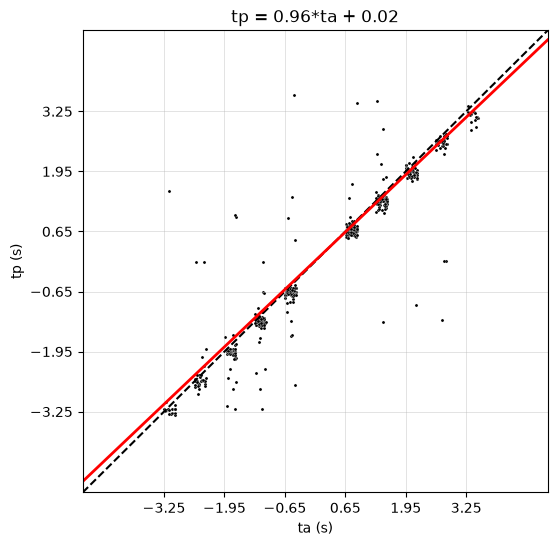

In [33]:
plt.figure(figsize=(6, 6))

sns.scatterplot(
    x=nts_df.loc[g_mask, "ta"] + jitter[g_mask],
    y=nts_df.loc[g_mask, "tp"],
    s=5,
    markers="o",
    color="k",
)

sns.lineplot(x=(-5, 5), y=(-5, 5), linestyle="--", color="k")

sns.lineplot(
    x=xx,
    y=tatplm.Coefficients.Estimate[1] * xx + tatplm.Coefficients.Estimate[0],
    # linestyle="--",
    color="r",
    linewidth=2
)

# sns.lineplot(
#     x=xx,
#     y=tatplmall.Coefficients.Estimate[1] * xx + tatplmall.Coefficients.Estimate[0],
#     # linestyle="--",
#     color="r",
#     linewidth=2
# )

plt.xlabel("ta (s)")
plt.xticks(np.arange(-3.25, 3.26, 1.3))

plt.ylabel("tp (s)")
plt.yticks(np.arange(-3.25, 3.26, 1.3))

plt.axis((-5, 5, -5, 5))
plt.grid(visible=True)
plt.title(
    f"tp = {round(tatplm.Coefficients.Estimate[1], 2)}*ta + {round(tatplm.Coefficients.Estimate[0], 2)}"
    # f", tp_all = {round(tatplmall.Coefficients.Estimate[1], 2)}*ta + {round(tatplmall.Coefficients.Estimate[0], 2)}"
)

plt.show()